# One 128K-token conversation outweighs the INT4 Llama-3.1-70B serving it

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## Two ceilings on the batch

In [1]:
L, G, D_HEAD, BYTES = 80, 8, 128, 2         # Llama-3.1-70B, bf16 cache
W, HBM, BW = 35e9, 80e9, 3.35e12            # INT4 weights, H100-80G
SLO = 80                                    # tokens/sec per user

kv_per_token = 2 * L * G * D_HEAD * BYTES   # K and V, every layer
step_budget = BW / SLO                      # bytes one decode step may move

print(f"KV per token: {kv_per_token:,} bytes")
for ctx in (1024, 4096, 16384, 32768, 131072):
    m_kv = kv_per_token * ctx
    b_slo = int((step_budget - W) // m_kv)  # bandwidth ceiling
    b_cap = int((HBM - W) // m_kv)          # memory ceiling
    b = min(b_slo, b_cap)
    line = f"{ctx:>7,} ctx  {m_kv/1e9:5.2f} GB  B_slo {b_slo:2d}  B_cap {b_cap:3d}"
    if b == 0:                              # SLO unreachable: fill the card instead
        b, line = b_cap, line + "  no SLO, filled"
    tput = b * BW / (W + b * m_kv)          # aggregate tokens/sec
    usd = 3 / (3600 * tput * 0.8) * 1e6     # $3/GPU-hour, 80% duty cycle
    print(line + f"  {tput:5.0f} tok/s ({tput / b:3.0f}/user)  ${usd:5.2f} per M tokens")

KV per token: 327,680 bytes
  1,024 ctx   0.34 GB  B_slo 20  B_cap 134   1606 tok/s ( 80/user)  $ 0.65 per M tokens
  4,096 ctx   1.34 GB  B_slo  5  B_cap  33    402 tok/s ( 80/user)  $ 2.59 per M tokens
 16,384 ctx   5.37 GB  B_slo  1  B_cap   8     83 tok/s ( 83/user)  $12.55 per M tokens
 32,768 ctx  10.74 GB  B_slo  0  B_cap   4  no SLO, filled    172 tok/s ( 43/user)  $ 6.06 per M tokens
131,072 ctx  42.95 GB  B_slo  0  B_cap   1  no SLO, filled     43 tok/s ( 43/user)  $24.24 per M tokens


## The figure

In [2]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

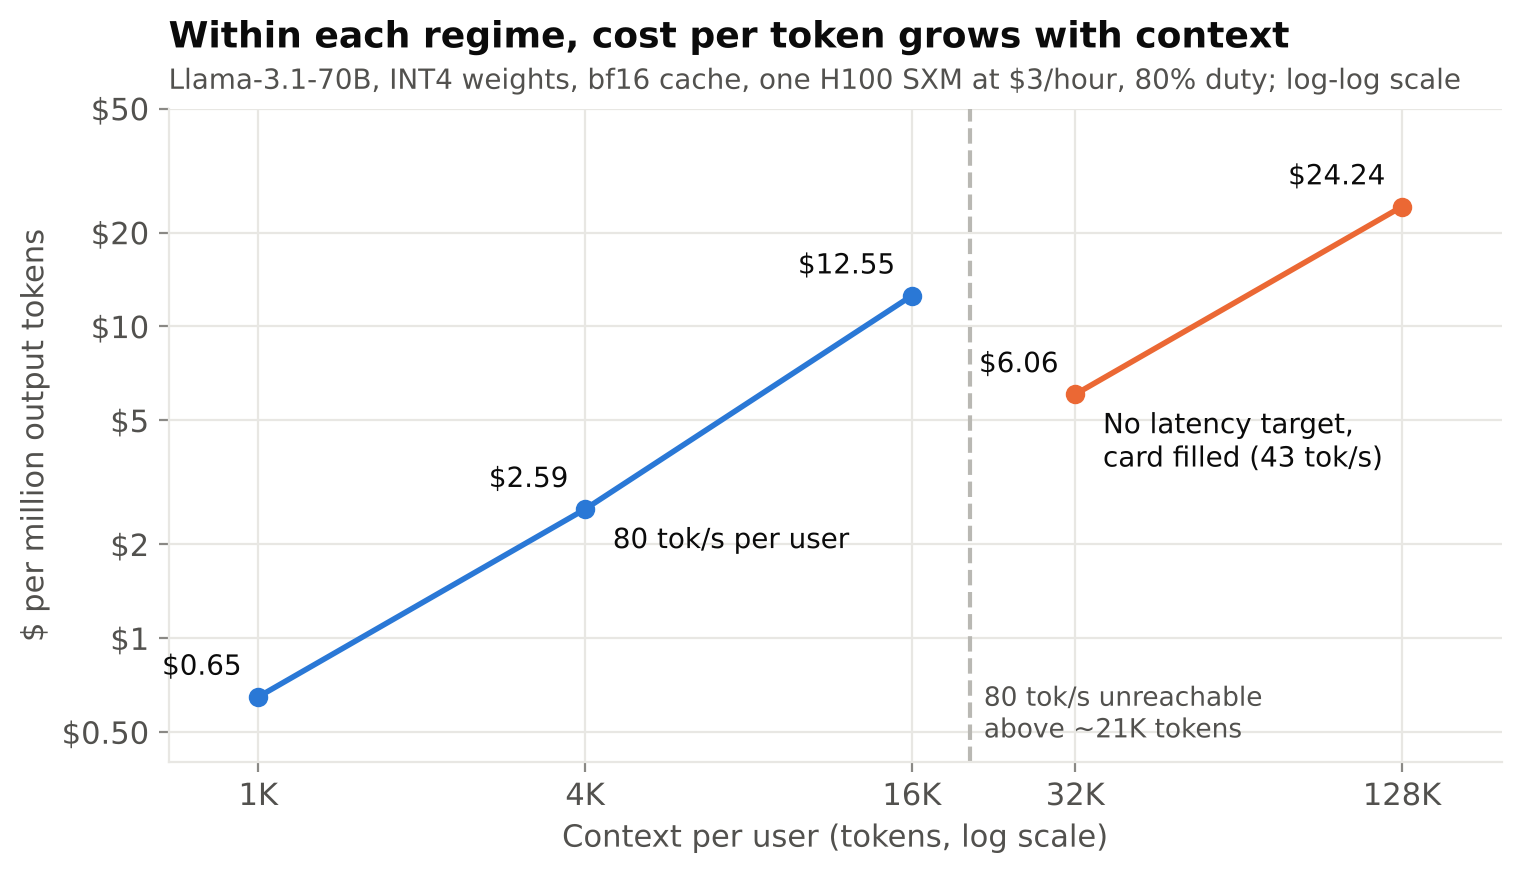

In [3]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib

    # Same constants and arithmetic as the article's script (Llama-3.1-70B, H100 SXM 80 GB)
    L, G, D_HEAD, BYTES = 80, 8, 128, 2
    W, HBM, BW, SLO = 35e9, 80e9, 3.35e12, 80
    kv = 2 * L * G * D_HEAD * BYTES
    budget = BW / SLO

    def cost(ctx, b):
        m = kv * ctx
        tput = b * BW / (W + b * m)
        return 3 / (3600 * tput * 0.8) * 1e6

    slo_ctx = [1024, 4096, 16384]
    slo_cost = [cost(c, int((budget - W) // (kv * c))) for c in slo_ctx]
    mem_ctx = [32768, 131072]
    mem_cost = [cost(c, int((HBM - W) // (kv * c))) for c in mem_ctx]
    limit = (budget - W) / kv            # one user's cache fills the SLO budget
    print([round(c, 2) for c in slo_cost], [round(c, 2) for c in mem_cost], round(limit))

    f, ax = fig()
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.axvline(limit, color=NEUTRAL, lw=1.5, ls="--")
    ax.text(limit * 1.06, 0.45, "80 tok/s unreachable\nabove ~21K tokens",
            color=INK_2, fontsize=9.5, va="bottom")
    ax.plot(slo_ctx, slo_cost, color=S1, marker="o")
    ax.plot(mem_ctx, mem_cost, color=S2, marker="o")
    for x, y in zip(slo_ctx, slo_cost):
        ax.annotate(f"${y:.2f}", (x, y), xytext=(-6, 8), textcoords="offset points",
                    ha="right", color=INK, fontsize=10)
    for x, y in zip(mem_ctx, mem_cost):
        ax.annotate(f"${y:.2f}", (x, y), xytext=(-6, 8), textcoords="offset points",
                    ha="right", color=INK, fontsize=10)
    ax.annotate("80 tok/s per user", (slo_ctx[1], slo_cost[1]), xytext=(10, -14),
                textcoords="offset points", color=INK, fontsize=10)
    ax.annotate("No latency target,\ncard filled (43 tok/s)", (mem_ctx[0], mem_cost[0]),
                xytext=(10, -26), textcoords="offset points", color=INK, fontsize=10)
    ticks = [1024, 4096, 16384, 32768, 131072]
    ax.set_xticks(ticks, ["1K", "4K", "16K", "32K", "128K"])
    ax.set_xticks([], minor=True)
    ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50], ["$0.50", "$1", "$2", "$5", "$10", "$20", "$50"])
    ax.set_yticks([], minor=True)
    ax.set_xlim(700, 200000); ax.set_ylim(0.4, 50)
    ax.set_xlabel("Context per user (tokens, log scale)")
    ax.set_ylabel("$ per million output tokens")
    ax.set_title("Within each regime, cost per token grows with context")
    subtitle(ax, "Llama-3.1-70B, INT4 weights, bf16 cache, one H100 SXM at $3/hour, 80% duty; log-log scale")
    path = pathlib.Path(__file__).parent / "06-kv-cost-vs-context.png"
    save(f, path)
import matplotlib.pyplot as plt
plt.show()